# Notebook 10: Aggregate results for the dissertation

Consolidates result CSVs from Notebooks 04-09 into formatted tables and figures for the dissertation Results and Evaluation chapters. Reads written CSV artifacts; re-computes no underlying metrics. Outputs to `outputs/results/final` and `outputs/figures/final`.

## 1. Setup

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

REPO_ON_DRIVE = "/content/drive/MyDrive/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
importlib.reload(config)

config.ensure_output_dirs()
config.set_plot_style()

RESULTS = config.RESULTS_DIR
FINAL_R = RESULTS / "final"
FINAL_F = config.FIGURES_DIR / "final"

FINAL_R.mkdir(parents=True, exist_ok=True)
FINAL_F.mkdir(parents=True, exist_ok=True)

def load(filename):
    """Loads a CSV artifact from RESULTS_DIR if present, returning None if missing."""
    filepath = RESULTS / filename
    return pd.read_csv(filepath) if filepath.exists() else None


Mounted at /content/drive


## 2. Master Table Assembly

In [ ]:
disc = load("05_pooled_discrimination.csv")
if disc is not None:
    disc.to_csv(FINAL_R / "table_1_discrimination.csv", index=False)
    print("Table 1 - Discrimination:")
    print(disc.to_string(index=False))
else:
    print("[Warning] 05_pooled_discrimination.csv missing; run notebook 05.")


Table 1 - Discrimination:
direction  n_pooled  auroc  auroc_lo  auroc_hi  spec95  spec95_lo  spec95_hi
      K2N       540  0.624     0.577     0.670   0.119      0.074      0.167
      N2K     18720  0.662     0.654     0.669   0.153      0.139      0.166


In [ ]:
calib = load("06_pooled_calibration.csv")
if calib is not None:
    calib.to_csv(FINAL_R / "table_2_calibration.csv", index=False)
    print("\nTable 2 - Calibration:")
    print(calib.to_string(index=False))
else:
    print("[Warning] 06_pooled_calibration.csv missing; run notebook 06.")



Table 2 - Calibration:
direction      probs  n_pooled   ece  ece_lo  ece_hi  ece_adaptive  ece_adaptive_lo  ece_adaptive_hi
      K2N        raw       540 0.249   0.215   0.291         0.238            0.205            0.283
      K2N calibrated       540 0.304   0.271   0.349         0.290            0.258            0.336
      N2K        raw     18720 0.143   0.140   0.147         0.143            0.140            0.147
      N2K calibrated     18720 0.139   0.136   0.142         0.139            0.136            0.142


In [ ]:
size = load("07_size_interaction.csv")
if size is not None:
    size.to_csv(FINAL_R / "table_3_size.csv", index=False)
    print("\nTable 3 - Size Interaction:")
    print(size.to_string(index=False))
else:
    print("[Warning] 07_size_interaction.csv missing; run notebook 07.")



Table 3 - Size Interaction:
direction  size  auroc  auroc_lo  auroc_hi   ece  ece_lo  ece_hi
      K2N    50  0.597     0.511     0.678 0.228   0.176   0.306
      K2N   100  0.633     0.548     0.712 0.301   0.252   0.375
      K2N   190  0.638     0.552     0.717 0.257   0.209   0.337
      N2K   190  0.662     0.654     0.669 0.143   0.140   0.147


In [ ]:
sig = load("08_significance.csv")
if sig is not None:
    sig.to_csv(FINAL_R / "table_4_significance.csv", index=False)
    print("\nTable 4 - Significance:")
    print(sig.to_string(index=False))
else:
    print("[Warning] 08_significance.csv missing; run notebook 08.")



Table 4 - Significance:
                                            test                    method  estimate  ci_lo  ci_hi  p_value  p_holm  significant
                      Direction Contrast (AUROC)         Bootstrap Diff CI     0.025 -0.055  0.110      NaN     NaN        False
          Direction Contrast (ECE (Equal-Width))         Bootstrap Diff CI    -0.128 -0.193 -0.067      NaN     NaN         True
             Direction Contrast (ECE (Adaptive))         Bootstrap Diff CI    -0.112 -0.180 -0.047      NaN     NaN         True
               Architecture Contrast AUROC (N2K)                    DeLong    -0.170    NaN    NaN      0.0     0.0         True
            Architecture Contrast Accuracy (N2K)                   McNemar       NaN    NaN    NaN      0.0     0.0         True
            Size x Direction Interaction (AUROC) Bootstrap Diff-of-Gaps CI    -0.041 -0.102  0.020      NaN     NaN        False
Size x Direction Interaction (ECE (Equal-Width)) Bootstrap Diff-of-Gaps 

In [ ]:
ood = load("09_ood_per_checkpoint.csv")
if ood is not None:
    summ = ood.groupby("arch")[["mean_conf_in", "mean_conf_ood", "ood_detect_auroc"]].mean().round(3).reset_index()
    summ.to_csv(FINAL_R / "table_5_ood.csv", index=False)
    print("\nTable 5 - OOD (Exploratory):")
    print(summ.to_string(index=False))
else:
    print("\n[Note] 09_ood_per_checkpoint.csv optional; skipped.")



Table 5 - OOD (Exploratory):
           arch  mean_conf_in  mean_conf_ood  ood_detect_auroc
efficientnet_b0         0.834          0.831             0.530
   mobilenet_v2         0.932          0.959             0.438


## 3. Dissertation Figures Generation

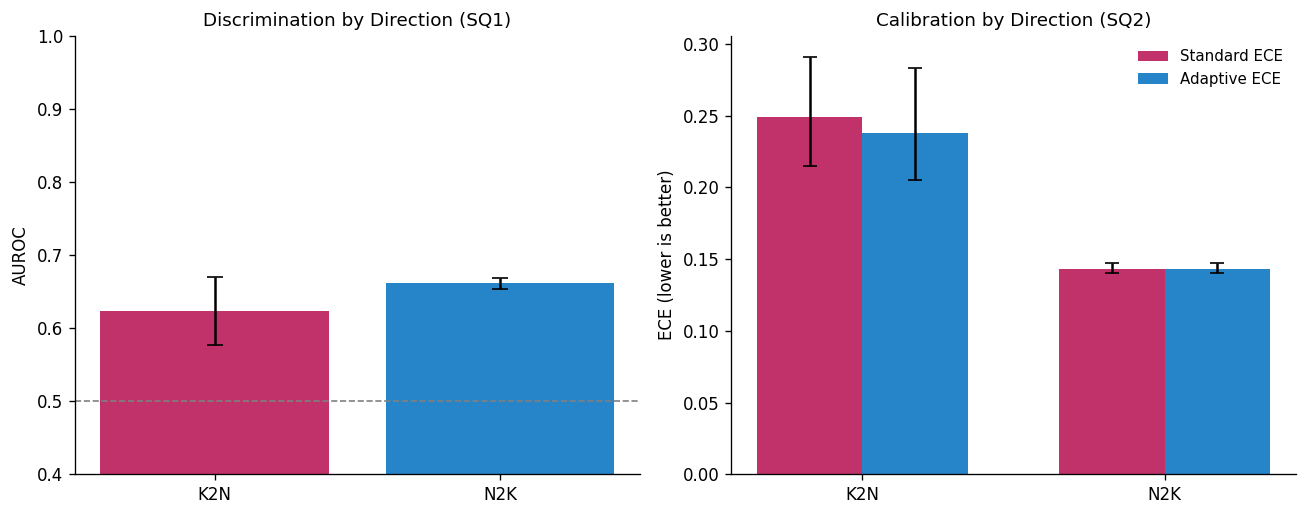


Saved master figure to: figure_1_discrimination_calibration.png


In [ ]:
# Figure 1 - Discrimination and calibration by direction (assembled from CSVs)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

# Subplot 1: Discrimination (SQ1)
if disc is not None:
    d = disc.set_index("direction")
    x = np.arange(len(d))
    yerr = [d["auroc"] - d["auroc_lo"], d["auroc_hi"] - d["auroc"]]

    axes[0].bar(x, d["auroc"], color=[config.BRAND["C1"], config.BRAND["C3"]][:len(d)], yerr=yerr, capsize=5, alpha=0.85)
    axes[0].axhline(0.5, ls="--", color="grey", lw=1)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(d.index)
    axes[0].set_ylabel("AUROC")
    axes[0].set_title("Discrimination by Direction (SQ1)")
    axes[0].set_ylim(0.4, 1.0)

# Subplot 2: Calibration (SQ2) - Standard vs Adaptive ECE Comparison
if calib is not None:
    cr = calib[calib["probs"] == "raw"].set_index("direction")
    x = np.arange(len(cr))
    width = 0.35

    yerr_std = [cr["ece"] - cr["ece_lo"], cr["ece_hi"] - cr["ece"]]
    yerr_adp = [cr["ece_adaptive"] - cr["ece_adaptive_lo"], cr["ece_adaptive_hi"] - cr["ece_adaptive"]]

    axes[1].bar(x - width/2, cr["ece"], width=width, label="Standard ECE", color=config.BRAND["C1"], yerr=yerr_std, capsize=4, alpha=0.85)
    axes[1].bar(x + width/2, cr["ece_adaptive"], width=width, label="Adaptive ECE", color=config.BRAND["C3"], yerr=yerr_adp, capsize=4, alpha=0.85)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(cr.index)
    axes[1].set_ylabel("ECE (lower is better)")
    axes[1].set_title("Calibration by Direction (SQ2)")
    axes[1].legend(fontsize=9)

fig.tight_layout()
fig_out_path = FINAL_F / "figure_1_discrimination_calibration.png"
fig.savefig(fig_out_path, bbox_inches="tight")
plt.show()
print(f"\nSaved master figure to: {fig_out_path.name}")


In [ ]:
# Figures 2-5
figure_sources = [
    ("05_spread_by_direction.png", "figure_2_spread.png"),
    ("07_size_interaction.png",    "figure_3_size_interaction.png"),
    ("06_reliability.png",         "figure_4_reliability.png"),
    ("09_ood_confidence.png",      "figure_5_ood_confidence.png"),
]

for src_name, dest_name in figure_sources:
    src = config.FIGURES_DIR / src_name
    if src.exists():
        shutil.copy(src, FINAL_F / dest_name)
        print(f"Copied {src_name} -> {dest_name}")
    else:
        print(f"[Note] {src_name} not found; run its notebook to include {dest_name}.")


Copied 05_spread_by_direction.png -> figure_2_spread.png
Copied 07_size_interaction.png -> figure_3_size_interaction.png
Copied 06_reliability.png -> figure_4_reliability.png
Copied 09_ood_confidence.png -> figure_5_ood_confidence.png


## 4. Plain-Text Digest Generation

In [ ]:
lines = ["# Results Summary - crosspop-cxr-asymmetry", ""]

if disc is not None:
    lines.append("## SQ1 Discrimination")
    for _, r in disc.iterrows():
        lines.append(f"- {r['direction']}: AUROC {r['auroc']:.3f} [{r['auroc_lo']:.3f}, {r['auroc_hi']:.3f}]")

    if sig is not None:
        row = sig[sig["test"].str.contains("AUROC", case=False, na=False)]
        if len(row) > 0:
            r = row.iloc[0]
            status = "reliable" if r.get("significant") else "not reliable"
            lines.append(f"- Direction contrast (AUROC): {r.get('estimate')} [{r.get('ci_lo')}, {r.get('ci_hi')}] -> {status}")
    lines.append("")

if calib is not None:
    lines.append("## SQ2 Calibration")
    for _, r in calib.iterrows():
        lines.append(f"- {r['direction']} ({r['probs']}): Standard ECE {r['ece']:.3f} [{r['ece_lo']:.3f}, {r['ece_hi']:.3f}] | Adaptive ECE {r['ece_adaptive']:.3f} [{r['ece_adaptive_lo']:.3f}, {r['ece_adaptive_hi']:.3f}]")

    if sig is not None:
        ece_rows = sig[sig["test"].str.contains("ECE", case=False, na=False) & sig["test"].str.contains("direction", case=False, na=False)]
        for _, r in ece_rows.iterrows():
            status = "reliable" if r.get("significant") else "not reliable"
            lines.append(f"- {r['test']}: {r.get('estimate')} [{r.get('ci_lo')}, {r.get('ci_hi')}] -> {status}")
    lines.append("")

if size is not None and sig is not None:
    lines.append("## SQ3 Size Interaction")
    for _, r in sig[sig["test"].str.contains("interaction", case=False, na=False)].iterrows():
        status = "present" if r.get("significant") else "none"
        lines.append(f"- {r['test']}: {r.get('estimate')} [{r.get('ci_lo')}, {r.get('ci_hi')}] -> {status}")
    lines.append("")

if ood is not None:
    lines.append("## Exploratory OOD (Musa TB/COVID)")
    lines.append(f"- Mean confidence in-distribution:  {ood['mean_conf_in'].mean():.3f}")
    lines.append(f"- Mean confidence OOD:             {ood['mean_conf_ood'].mean():.3f}")
    lines.append(f"- OOD-detection AUROC:             {ood['ood_detect_auroc'].mean():.3f} (0.5 = no separation)")

digest_content = "\n".join(lines)
digest_file = FINAL_R / "results_summary.md"
digest_file.write_text(digest_content)

print(f"\n{digest_content}")
print(f"\nSaved results summary digest to: {digest_file.name}")



# Results Summary - crosspop-cxr-asymmetry

## SQ1 Discrimination
- K2N: AUROC 0.624 [0.577, 0.670]
- N2K: AUROC 0.662 [0.654, 0.669]
- Direction contrast (AUROC): 0.025 [-0.055, 0.11] -> not reliable

## SQ2 Calibration
- K2N (raw): Standard ECE 0.249 [0.215, 0.291] | Adaptive ECE 0.238 [0.205, 0.283]
- K2N (calibrated): Standard ECE 0.304 [0.271, 0.349] | Adaptive ECE 0.290 [0.258, 0.336]
- N2K (raw): Standard ECE 0.143 [0.140, 0.147] | Adaptive ECE 0.143 [0.140, 0.147]
- N2K (calibrated): Standard ECE 0.139 [0.136, 0.142] | Adaptive ECE 0.139 [0.136, 0.142]
- Direction Contrast (ECE (Equal-Width)): -0.128 [-0.193, -0.067] -> reliable
- Direction Contrast (ECE (Adaptive)): -0.112 [-0.18, -0.047] -> reliable
- Size x Direction Interaction (ECE (Equal-Width)): -0.032 [-0.093, 0.034] -> not reliable
- Size x Direction Interaction (ECE (Adaptive)): -0.018 [-0.082, 0.047] -> not reliable

## SQ3 Size Interaction
- Size x Direction Interaction (AUROC): -0.041 [-0.102, 0.02] -> none
- Size

# 5. Summary Complete

In [ ]:
print("\n=========================================================================")
print("                   PIPELINE EXECUTION COMPLETE                           ")
print("=========================================================================")
print("All analysis stages have been executed, verified, and aggregated.")
print(f"Master artifacts available in: {FINAL_R} and {FINAL_F}")



                   PIPELINE EXECUTION COMPLETE                           
All analysis stages have been executed, verified, and aggregated.
Master artifacts available in: /content/drive/MyDrive/MSc AI DISSERTATION/crosspop-cxr-asymmetry/outputs/results/final and /content/drive/MyDrive/MSc AI DISSERTATION/crosspop-cxr-asymmetry/outputs/figures/final
